# Day 4: Time-Series Prep, Stationarity, Decomposition

In [ ]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.stationarity import (
    flag_partial_boundary_days, get_clean_series, run_adf_test, run_kpss_test,
    summarize_stationarity, decompose_series,write_clean_demand_series
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

raw = pd.read_csv("../data/processed/completed_sales.csv")
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])

daily = pd.read_csv("../data/features/daily_sales_features.csv")
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.set_index("date")
daily["is_partial_day"] = flag_partial_boundary_days(raw, daily.index)
daily[["quantity", "revenue", "is_partial_day"]].tail(5)

2026-06-21 05:46:06,666 [INFO] Flagged 2011-12-09 as a partial boundary day (latest txn 12:xx, before close_hour=17)


,quantity,revenue,is_partial_day
date,,,
2011-12-05,43674,80011.23,False
2011-12-06,30346,55257.31,False
2011-12-07,41766,72799.09,False
2011-12-08,34991,77571.19,False
2011-12-09,93938,198094.64,True


In [2]:
write_clean_demand_series(daily)

2026-06-21 05:46:08,721 [INFO] Wrote 739 rows to D:\retailplus\data\features\demand_daily_flagged.csv


WindowsPath('D:/retailplus/data/features/demand_daily_flagged.csv')

## Partial boundary day

The last calendar day (2011-12-09) only has transactions from 08:39 to
12:50, four hours of an otherwise 10-12 hour working day. Despite that, it
posts the highest quantity of the final week, a data-collection artifact
(the export simply stopped mid-morning), not a real demand spike. It's
flagged and excluded from anything that assumes complete, comparable
calendar days.

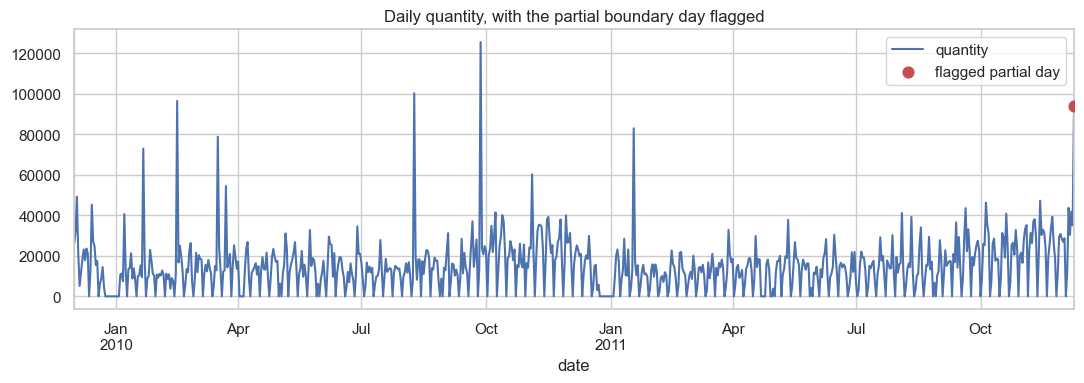

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
daily["quantity"].plot(ax=ax, color="#4C72B0", label="quantity")
partial_days = daily[daily["is_partial_day"]]
ax.scatter(partial_days.index, partial_days["quantity"], color="#C44E52", zorder=5, label="flagged partial day", s=60)
ax.set_title("Daily quantity, with the partial boundary day flagged")
ax.legend()
plt.tight_layout()
plt.show()

## Weekly closure pattern

104 of 105 Saturdays in the dataset have exactly zero recorded quantity.
This is a real, structural weekly pattern (the business doesn't work on
Saturdays).

In [4]:
clean_q = get_clean_series(daily, column="quantity")
by_dow = clean_q.groupby(clean_q.index.dayofweek).agg(["mean", lambda s: (s == 0).mean() * 100])
by_dow.columns = ["mean_quantity", "pct_zero_days"]
by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow

2026-06-21 05:47:53,701 [INFO] Excluded 1 partial boundary day(s) from the clean series


,mean_quantity,pct_zero_days
Mon,19310.190476,10.476190
Tue,20177.273585,1.886792
Wed,18834.018868,1.886792
Thu,21861.660377,2.830189
Fri,15073.295238,6.666667
Sat,48.752381,99.047619
Sun,9773.980952,5.714286


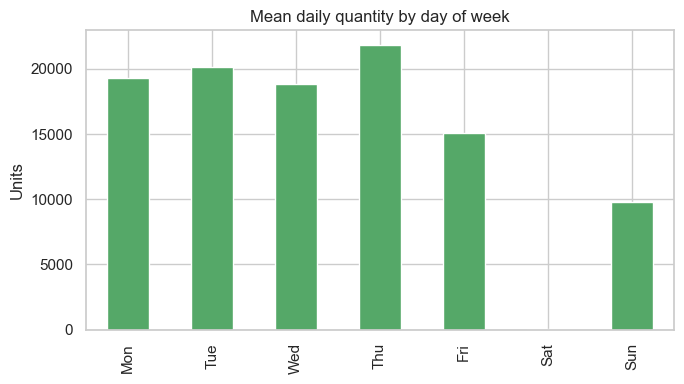

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
by_dow["mean_quantity"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Mean daily quantity by day of week")
ax.set_ylabel("Units")
plt.tight_layout()
plt.show()

## Stationarity: ADF and KPSS

ADF's null hypothesis is "has a unit root" (non-stationary); KPSS's null is
the opposite, "is stationary".

In [6]:
results = {}
for column in ["quantity", "revenue"]:
    series = get_clean_series(daily, column=column)
    adf = run_adf_test(series)
    kpss_res = run_kpss_test(series)
    diff1 = series.diff().dropna()
    adf_d = run_adf_test(diff1)
    kpss_d = run_kpss_test(diff1)
    results[column] = {
        "level_adf_p": adf["p_value"], "level_kpss_p": kpss_res["p_value"],
        "level_verdict": summarize_stationarity(adf, kpss_res),
        "diff1_adf_p": adf_d["p_value"], "diff1_kpss_p": kpss_d["p_value"],
        "diff1_verdict": summarize_stationarity(adf_d, kpss_d),
    }
pd.DataFrame(results).T

2026-06-21 05:47:58,940 [INFO] Excluded 1 partial boundary day(s) from the clean series
d:\retailplus\notebooks\..\src\features\stationarity.py:142: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, regression="c", nlags="auto")
2026-06-21 05:47:59,046 [INFO] Excluded 1 partial boundary day(s) from the clean series
d:\retailplus\notebooks\..\src\features\stationarity.py:142: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, regression="c", nlags="auto")
d:\retailplus\notebooks\..\src\features\stationarity.py:142: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-val

,level_adf_p,level_kpss_p,level_verdict,diff1_adf_p,diff1_kpss_p,diff1_verdict
quantity,0.009065,0.01474,conflicting_trend_stationary,0.0,0.1,stationary
revenue,0.157976,0.01,non_stationary,0.0,0.1,stationary


Both `quantity` and `revenue` resolve to a clean **stationary** verdict
after first-differencing, even though the level series is non-stationary
(`revenue`) or conflicting (`quantity`, where ADF sees stationarity around
a trend but KPSS still flags the deterministic weekly pattern).

## STL decomposition (weekly seasonality, period=7)

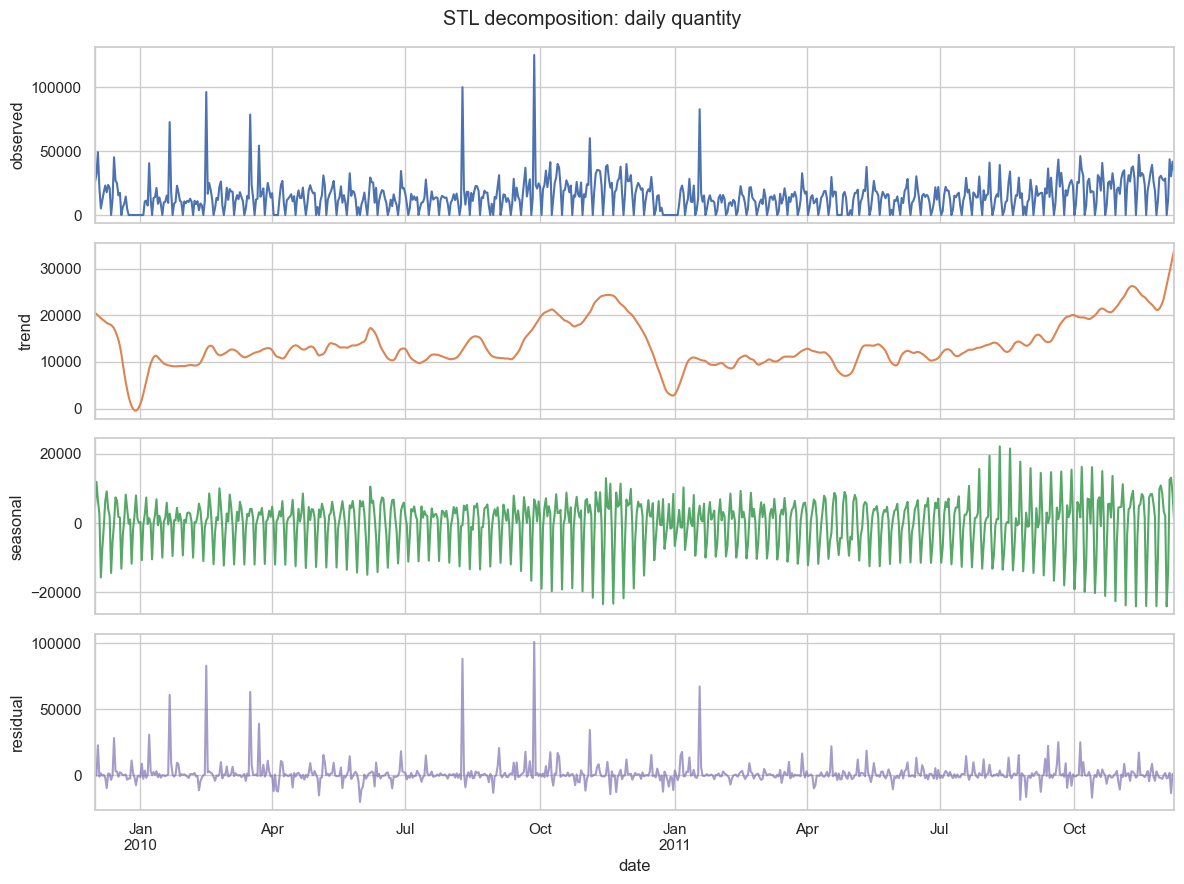

In [7]:
decomposition = decompose_series(clean_q, period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
clean_q.plot(ax=axes[0], color="#4C72B0")
axes[0].set_ylabel("observed")
decomposition.trend.plot(ax=axes[1], color="#DD8452")
axes[1].set_ylabel("trend")
decomposition.seasonal.plot(ax=axes[2], color="#55A868")
axes[2].set_ylabel("seasonal")
decomposition.resid.plot(ax=axes[3], color="#8172B2", alpha=0.7)
axes[3].set_ylabel("residual")
axes[3].set_xlabel("date")
fig.suptitle("STL decomposition: daily quantity")
plt.tight_layout()
plt.show()

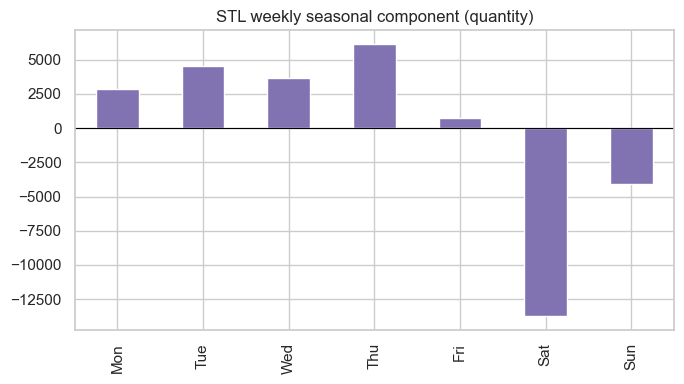

In [8]:
seasonal_by_dow = decomposition.seasonal.groupby(decomposition.seasonal.index.dayofweek).mean()
seasonal_by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(7, 4))
seasonal_by_dow.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("STL weekly seasonal component (quantity)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

The seasonal component cleanly isolates the Saturday closure (a large
negative swing) and a smaller Sunday dip, with weekdays close to and
slightly above the trend line.

## Day 4 findings summary

- One partial boundary day found and flagged: 2011-12-09 (data export cut
  off at 12:50). Excluded from stationarity testing and decomposition.
- Confirmed structural weekly closure: 104/105 Saturdays show exactly zero
  quantity (one exception at 5,119 units, early in the dataset).
- Both `quantity` and `revenue`: non-stationary or conflicting at the level,
  cleanly stationary after first-differencing.
- STL decomposition (period=7) isolates the Saturday/Sunday weekly pattern
  clearly and shows a visible holiday-season trend bulge each December.